In [2]:
print("hello world")

hello world


In [3]:
import torch
import torchvision
from torchvision import transforms,datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy

In [4]:
# define transform

train_transforms=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2,contrast=0.2),
    transforms.ToTensor(),                # convert image to tensor (numbers)
    transforms.Normalize(                 # normalize to what pretrained model expects
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [5]:
# load data

traindata_dir="../dataset/train"
valdata_dir="../dataset/valid"

train_dataset=datasets.ImageFolder(root=traindata_dir,transform=train_transforms)
valid_dataset=datasets.ImageFolder(root=valdata_dir,transform=val_transforms)

print(f"Classes found: {train_dataset.classes}")
print(f"Class mapping: {train_dataset.class_to_idx}")
print(f"Total images train:  {len(train_dataset)}")


# print(f"Classes found: {valid_dataset.classes}")
# print(f"Class mapping: {valid_dataset.class_to_idx}")
print(f"Total images val:  {len(valid_dataset)}")

Classes found: ['ace of clubs', 'ace of diamonds', 'ace of hearts', 'ace of spades', 'eight of clubs', 'eight of diamonds', 'eight of hearts', 'eight of spades', 'five of clubs', 'five of diamonds', 'five of hearts', 'five of spades', 'four of clubs', 'four of diamonds', 'four of hearts', 'four of spades', 'jack of clubs', 'jack of diamonds', 'jack of hearts', 'jack of spades', 'joker', 'king of clubs', 'king of diamonds', 'king of hearts', 'king of spades', 'nine of clubs', 'nine of diamonds', 'nine of hearts', 'nine of spades', 'queen of clubs', 'queen of diamonds', 'queen of hearts', 'queen of spades', 'seven of clubs', 'seven of diamonds', 'seven of hearts', 'seven of spades', 'six of clubs', 'six of diamonds', 'six of hearts', 'six of spades', 'ten of clubs', 'ten of diamonds', 'ten of hearts', 'ten of spades', 'three of clubs', 'three of diamonds', 'three of hearts', 'three of spades', 'two of clubs', 'two of diamonds', 'two of hearts', 'two of spades']
Class mapping: {'ace of cl

In [6]:
train_loader=DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)
val_loader = DataLoader(
    valid_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)
print(f"Training batches:   {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Training batches:   239
Validation batches: 9


In [7]:
# grab one batch and inspect it
images, labels = next(iter(train_loader))

print(f"Batch image shape: {images.shape}")   # should be [32, 3, 224, 224]
print(f"Batch label shape: {labels.shape}")   # should be [32]
print(f"Label values:      {labels}")         
print(f"Pixel value range: {images.min():.2f} to {images.max():.2f}")

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])
Label values:      tensor([24, 44, 34, 25, 18, 21, 17, 19, 24, 16, 47,  9,  4, 30,  2,  4, 10, 43,
         7, 30, 23,  0, 15, 21,  2, 42, 40,  3,  8, 13, 41,  5])
Pixel value range: -2.12 to 2.64


In [18]:
import torch.nn as nn

model=torchvision.models.mobilenet_v3_small(weights="IMAGENET1K_V1")

for param in model.parameters():
    param.requires_grad = False

model.classifier[3]=nn.Linear(model.classifier[3].in_features, 53)

for param in model.features[-3:].parameters():
    param.requires_grad = True

# Make sure classifier is trainable
for param in model.classifier.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"Trainable params: {trainable:,} out of {total_params:,}")
print("Model ready!")

Trainable params: 1,289,813 out of 1,572,181
Model ready!


In [19]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")   # cpu or mps

model = model.to(device)

criterion = nn.CrossEntropyLoss()           # loss function for classification
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4                              # learning rate
)

Using device: mps


In [22]:
from tqdm import tqdm

EPOCHS = 20
best_val_acc = 0.0

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []


for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0, 0, 0

    for images,labels in tqdm(train_loader,desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs=model(images)
        loss=criterion(outputs,labels)
        loss.backward()
        optimizer.step()

        running_loss +=loss.item()
        _,predicted=outputs.max(1)
        correct+=predicted.eq(labels).sum().item()
        total   += labels.size(0)
    train_loss = running_loss / len(train_loader)
    train_acc  = 100. * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    # ── validation phase ──

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images,labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss+=loss.item()

            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total   += labels.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc  = 100. * val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1:02d} | "
          f"Train loss: {train_loss:.3f} | Train acc: {train_acc:.1f}% | "
          f"Val loss: {val_loss:.3f} | Val acc: {val_acc:.1f}%")

    # save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "../models/best_model.pth")
        print(f"   ✓ Best model saved ({val_acc:.1f}%)")

print(f"\nTraining complete! Best validation accuracy: {best_val_acc:.1f}%")


Epoch 1/20: 100%|██████████| 239/239 [00:20<00:00, 11.52it/s]


Epoch 01 | Train loss: 0.695 | Train acc: 79.3% | Val loss: 0.564 | Val acc: 81.5%
   ✓ Best model saved (81.5%)


Epoch 2/20: 100%|██████████| 239/239 [00:20<00:00, 11.42it/s]


Epoch 02 | Train loss: 0.653 | Train acc: 80.4% | Val loss: 0.505 | Val acc: 81.5%


Epoch 3/20: 100%|██████████| 239/239 [00:20<00:00, 11.60it/s]


...

Epoch 08 | Train loss: 0.442 | Train acc: 86.8% | Val loss: 0.479 | Val acc: 84.5%


Epoch 9/20: 100%|██████████| 239/239 [00:20<00:00, 11.62it/s]


Epoch 09 | Train loss: 0.414 | Train acc: 87.3% | Val loss: 0.435 | Val acc: 86.4%
   ✓ Best model saved (86.4%)


Epoch 10/20: 100%|██████████| 239/239 [00:20<00:00, 11.61it/s]


KeyboardInterrupt: 

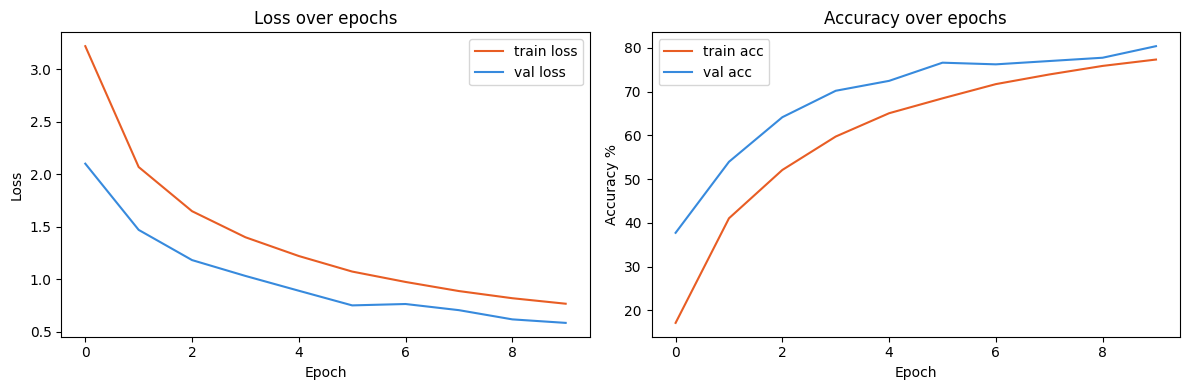

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label="train loss", color="#E85D24")
ax1.plot(val_losses,   label="val loss",   color="#378ADD")
ax1.set_title("Loss over epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(train_accs, label="train acc", color="#E85D24")
ax2.plot(val_accs,   label="val acc",  color="#378ADD")
ax2.set_title("Accuracy over epochs")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy %")
ax2.legend()

plt.tight_layout()
plt.show()